In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from MDPSetup import create_state_space, create_action_space, create_P, create_R, cL_value_update_func
from ValueIteration import *
from ParallelValueIteration import value_iteration_parallel
from typing import Tuple, List

# 2-echelon problem with lead times at DC only

## Centralised problem

In [39]:
# Problem parameters
capacity = (-400, 800)
increment = 100
lead_times = [1, 1]
n_ech = 2
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
max_demand = max(demand_dist.keys())
hold_costs = [1, 0.5]
backlog_costs = [50, 25]

# Perform value iteration
gamma = 0.999
S, state_idx = create_state_space(capacity, increment, n_ech, max_demand, lead_times)
A, action_idx = create_action_space(capacity, increment, n_ech, max_demand)
P = create_P(S, A, state_idx, action_idx, demand_dist, capacity, n_ech, lead_times)

In [40]:
R = create_R(S, A, state_idx, action_idx, P, demand_dist, hold_costs, backlog_costs, capacity, n_ech, lead_times)

In [41]:
bellman_eq_cL = cL_value_update_func(S, A, state_idx, action_idx, P, capacity, demand_dist, n_ech, lead_times)
V_init = dict([(s, 0) for s in S])


In [42]:
print(len(S), len(A))

28561 169


In [43]:

cL_results = value_iteration(S, A, P, R, gamma, max_iterations = 100,
                                 bellman_eq=bellman_eq_cL, V_init = V_init, theta = 1e-7)
cL_optimal_policy = cL_results["optimal_policy"]
cL_cost_function = cL_results["value_function"]

35000.0
24975.0
3193.6032000000014
947.2526491500003
846.7546470506995
746.4566937029504
651.8410741529751
578.1955481526247
525.9689245064837
482.47470608533513
438.8757749464967
393.4014458213187
348.60615870748006
308.7951745424525
277.4463151132986
255.56641167713315
241.8828299287943
234.08989476516763
229.96462822035028
227.8756718670411
226.81613747824485
226.23795530449024
225.87052580918134
225.5903696555506
225.3447080811584
225.1121965796392
224.88460401973498
224.6588847835228
224.43395210190465
224.20943038420046
223.9851934075523
223.76119973378263
223.53743596921413
223.31389777011464
223.09058364869998
222.86749300041447
222.64462548898337
222.42198085830023
222.19955887599644
221.97735931671923
221.75538195729678
221.53362657530852
221.3120929487268
221.0907808557822
220.86969007492007
220.64882038484575
220.42817156446108
220.20774339290801
219.98753564950312
219.76754811385763
219.54778056574287
219.32823278517753
219.10890455239132
218.88979564784677
218.67090585219

In [ ]:

# cL_results = value_iteration_parallel(S, A, P, R, gamma, max_iterations = 100,
#                                  bellman_eq=bellman_eq_2cL, V_init = V_init, theta = 1e-7)
# cL_optimal_policy = cL_results["optimal_policy"]
# cL_cost_function = cL_results["value_function"]

In [44]:
cL_optimal_policy

{(-400, -400, 0, 0): (0, 600),
 (-400, -400, 0, 100): (0, 600),
 (-400, -400, 0, 200): (0, 600),
 (-400, -400, 0, 300): (0, 500),
 (-400, -400, 0, 400): (0, 400),
 (-400, -400, 0, 500): (100, 300),
 (-400, -400, 0, 600): (200, 200),
 (-400, -400, 0, 700): (200, 100),
 (-400, -400, 0, 800): (200, 0),
 (-400, -400, 0, 900): (200, 0),
 (-400, -400, 0, 1000): (200, 0),
 (-400, -400, 0, 1100): (200, 0),
 (-400, -400, 0, 1200): (200, 0),
 (-400, -400, 100, 0): (0, 600),
 (-400, -400, 100, 100): (0, 600),
 (-400, -400, 100, 200): (0, 600),
 (-400, -400, 100, 300): (0, 500),
 (-400, -400, 100, 400): (0, 400),
 (-400, -400, 100, 500): (100, 300),
 (-400, -400, 100, 600): (200, 200),
 (-400, -400, 100, 700): (200, 100),
 (-400, -400, 100, 800): (200, 0),
 (-400, -400, 100, 900): (200, 0),
 (-400, -400, 100, 1000): (200, 0),
 (-400, -400, 100, 1100): (200, 0),
 (-400, -400, 100, 1200): (200, 0),
 (-400, -400, 200, 0): (0, 600),
 (-400, -400, 200, 100): (0, 600),
 (-400, -400, 200, 200): (0, 500),

In [52]:
max(A)[0]

1200

In [53]:
store_results(cL_results, 2, f"c{lead_times[0]}-{lead_times[1]}", max(S)[0], max(A)[0], backlog_costs, hold_costs, gamma)


# Plotting Code
## Plotting functions

In [54]:
def calculate_ip(state: tuple, lead_times: List, n_ech: int):
    ''' Calculates the inventory position for each site in the supply chain'''
    ips = []
    next_lead_idx = n_ech
    for ech in range(n_ech): # for each site
        ips.append(state[ech] + sum(state[next_lead_idx:next_lead_idx+lead_times[ech]])) # add inventory level + outstanding orders for the current site
        next_lead_idx += lead_times[ech]

    return tuple(ips)

def make_policy_plot_dict(optimal_dict: Dict, lead_times: List, n_ech: int, system_type: str ="Centralised"):
    IPs = sorted(set(calculate_ip(state, lead_times, n_ech) for state in optimal_dict)) 
    
    W_policy = dict((ip_dc, set()) for (ip_dc, ip_w) in IPs)

    if system_type == "Centralised":
        DC_policy = dict((ip_w, set()) for (ip_dc, ip_w) in IPs)

        for state, (q_dc, q_w) in optimal_dict.items():
            ip_dc, ip_w = calculate_ip(state, lead_times, n_ech)

            W_policy[ip_dc].add((ip_w, q_w))
            DC_policy[ip_w].add((ip_dc, q_dc))

        return W_policy, DC_policy

    
    # else: # COMPLETE FOR DECENTRALISED SYSTEM



def generate_policy_plot(optimal_dict: Dict, bounds: tuple, 
                         lead_times: List, n_ech: int, system_type: str = "Centralised", 
                         colour_by: str = "DC", bbox_to_anchor=None, savefig=False):
    if system_type == "Centralised":
        W_policy, DC_policy = make_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)
    else:
        W_policy = make_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)

    
    plot_pol = W_policy if colour_by == "DC" else DC_policy
    x_site = "warehouse" if colour_by == "DC" else "DC"

    cmap = plt.get_cmap("tab20")
    keys = sorted(plot_pol.keys())
    colors = cmap([i / (len(keys) - 1) for i in range(len(keys))])

    fig, ax = plt.subplots()

    for il, color in zip(keys, colors):
        if bounds[0] <= il <= bounds[1]:
            sorted_pol = sorted(plot_pol[il])
            ips, order_sizes = zip(*sorted_pol)
            label = il if bounds[0] < il < bounds[1] else rf"$\geq {bounds[1]}$" if il >= bounds[1] else rf"$\leq {bounds[0]}$"
            plt.plot(ips, order_sizes, label=label, color=color, linestyle="--", linewidth=1, marker = ".", markersize=10)

    
    # filename=f"Figures/multi_echelon/policy_{'c0' if system_type=='centralised' else 'dc0'}_leg{colour_by}_cap{capacity}_MOQ{maxA}_sl{cb[0]*100/(cb[0]+h[0]):.1f}.{format}"   # filename
    plt.xlabel(f"Inventory position at {x_site}", fontsize=18)
    plt.ylabel("Optimal order quantity", fontsize=18)
    # plt.title(f"Optimal policy at {x_site} coloured by inventory position at {colour_by}")
    plt.legend(title=f"{colour_by} IP", bbox_to_anchor=bbox_to_anchor, fontsize=14, title_fontsize=14)
    plt.grid()
    plt.tight_layout()
    # if savefig:
    #     plt.savefig(filename, dpi=300)
    plt.show()



In [22]:
def calculate_echelon_ip(state: tuple, lead_times: List, n_ech: int):
    ''' Calculates the inventory position for each site in the supply chain'''
    ips = calculate_ip(state, lead_times, n_ech)
    ech_ips = [ips[0]]
    for ech in range(1, n_ech): # for each site
        ech_ips.append(ips[ech] + sum(ech_ips))

    return tuple(ech_ips)

def make_echelon_policy_plot_dict(optimal_dict: Dict, lead_times: List, n_ech: int, system_type: str ="Centralised"):
    ech_IPs = sorted(set(calculate_echelon_ip(state, lead_times, n_ech) for state in optimal_dict)) 
    
    W_policy = dict((ip_dc, set()) for (ip_dc, ip_w) in ech_IPs)

    if system_type == "Centralised":
        DC_policy = dict((ip_w, set()) for (ip_dc, ip_w) in ech_IPs)

        for state, (q_dc, q_w) in optimal_dict.items():
            ip_dc, ip_w = calculate_echelon_ip(state, lead_times, n_ech)

            W_policy[ip_dc].add((ip_w, q_w))
            DC_policy[ip_w].add((ip_dc, q_dc))

        return W_policy, DC_policy
    
def generate_echelon_policy_plot(optimal_dict: Dict, bounds: tuple, 
                         lead_times: List, n_ech: int, system_type: str = "Centralised", 
                         colour_by: str = "DC", bbox_to_anchor=None, savefig=False):
    if system_type == "Centralised":
        W_policy, DC_policy = make_echelon_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)
    else:
        W_policy = make_echelon_policy_plot_dict(optimal_dict, lead_times, n_ech, system_type)

    
    plot_pol = W_policy if colour_by == "DC" else DC_policy
    x_site = "warehouse" if colour_by == "DC" else "DC"

    cmap = plt.get_cmap("tab20")
    keys = sorted(plot_pol.keys())
    colors = cmap([i / (len(keys) - 1) for i in range(len(keys))])

    fig, ax = plt.subplots()

    for il, color in zip(keys, colors):
        if bounds[0] <= il <= bounds[1]:
            sorted_pol = sorted(plot_pol[il])
            ips, order_sizes = zip(*sorted_pol)
            label = il if bounds[0] < il < bounds[1] else rf"$\geq {bounds[1]}$" if il >= bounds[1] else rf"$\leq {bounds[0]}$"
            plt.plot(ips, order_sizes, label=label, color=color, linestyle="--", linewidth=1, marker = ".", markersize=10)

    
    # filename=f"Figures/multi_echelon/policy_{'c0' if system_type=='centralised' else 'dc0'}_leg{colour_by}_cap{capacity}_MOQ{maxA}_sl{cb[0]*100/(cb[0]+h[0]):.1f}.{format}"   # filename
    plt.xlabel(f"Echelon inventory position at {x_site}", fontsize=18)
    plt.ylabel("Optimal order quantity", fontsize=18)
    # plt.title(f"Optimal policy at {x_site} coloured by inventory position at {colour_by}")
    plt.legend(title=f"{colour_by} IP", bbox_to_anchor=bbox_to_anchor, fontsize=14, title_fontsize=14)
    plt.grid()
    plt.tight_layout()
    # if savefig:
    #     plt.savefig(filename, dpi=300)
    plt.show()
    

/tmp/ipykernel_584881/2798256649.py:64: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


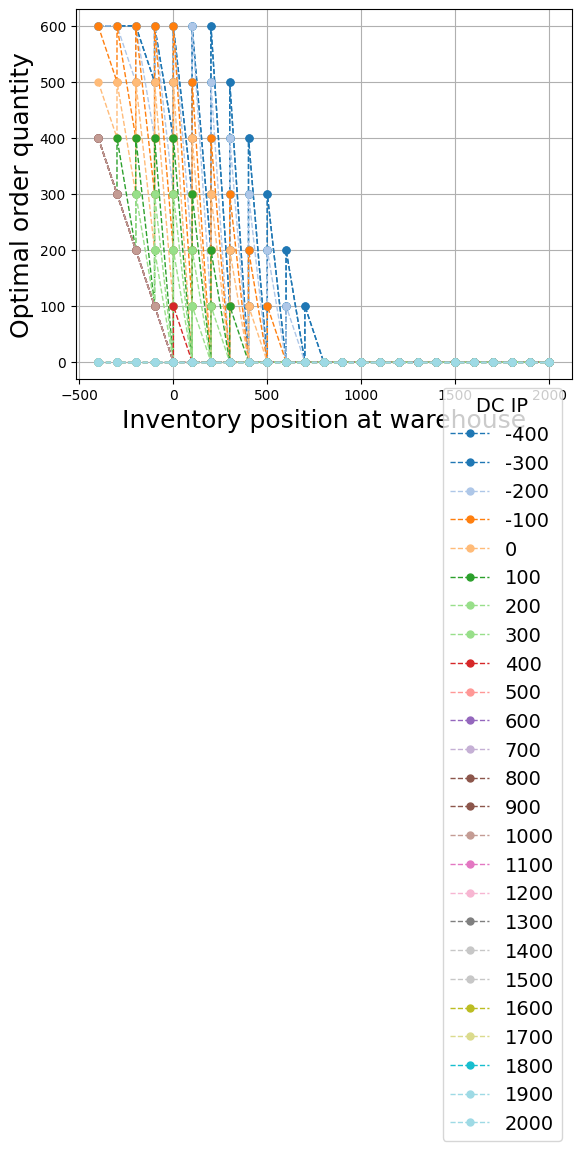

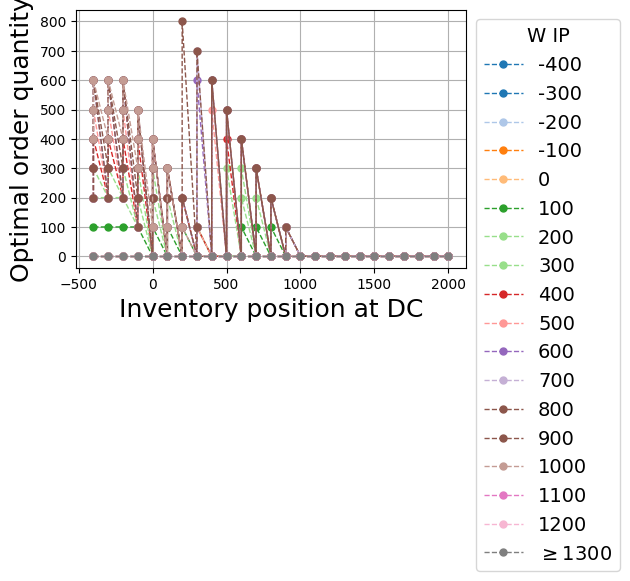

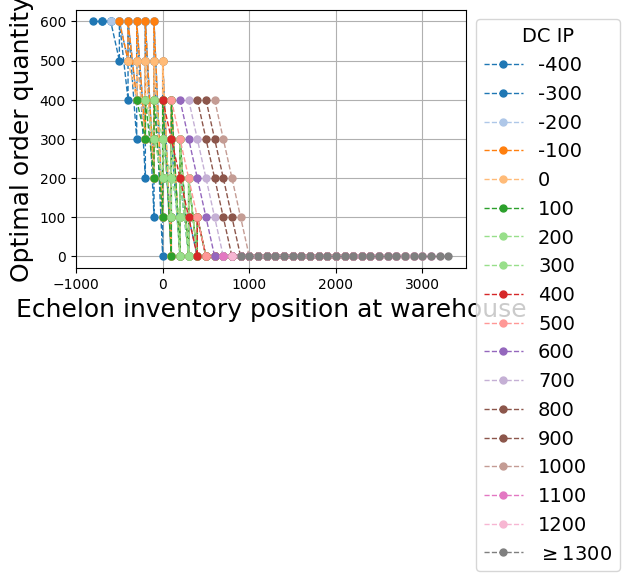

/tmp/ipykernel_584881/2435359643.py:58: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


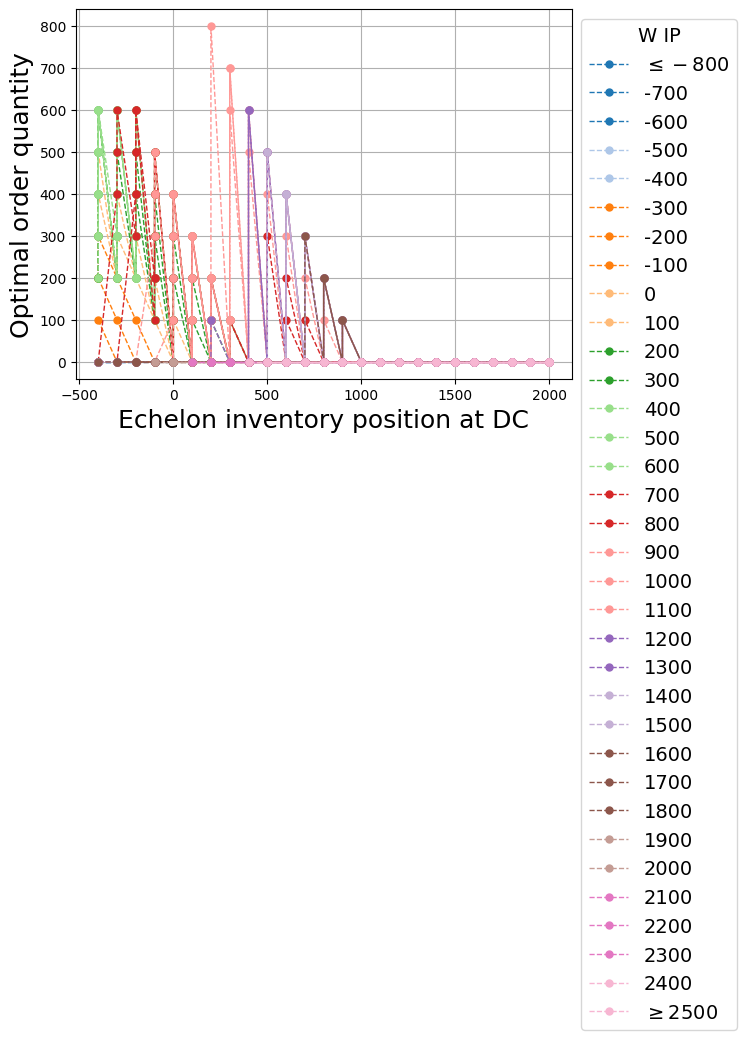

In [74]:
# make_policy_plot_dict(cL_optimal_policy, lead_times, 2)[0]
generate_policy_plot(cL_optimal_policy, (-1000, 2100), lead_times, n_ech=2, colour_by="DC",  bbox_to_anchor=(1, 0))
generate_policy_plot(cL_optimal_policy, (-1000, 1300), lead_times, n_ech=2, colour_by="W", bbox_to_anchor=(1, 1))

generate_echelon_policy_plot(cL_optimal_policy, (-500, 1300), lead_times, n_ech=2, colour_by="DC",  bbox_to_anchor=(1, 1))
generate_echelon_policy_plot(cL_optimal_policy, (-800, 2500), lead_times, n_ech=2, colour_by="W", bbox_to_anchor=(1, 1))

In [57]:
def make_cost_plot_dict(optimal_dict, lead_times, n_ech):
    IPs = sorted(set(calculate_ip(state, lead_times, n_ech) for state in optimal_dict)) 
    
    W_cost = dict((ip_dc, set()) for (ip_dc, ip_w) in IPs)
    DC_cost = dict((ip_w, set()) for (ip_dc, ip_w) in IPs)
    
    for state, cost in optimal_dict.items():
        ip_dc, ip_w = calculate_ip(state, lead_times, n_ech)

        W_cost[ip_dc].add((ip_w, cost))
        DC_cost[ip_w].add((ip_dc, cost))

    return W_cost, DC_cost
    
def plot_cost(optimal_dict, lead_times, n_ech, colour_by="W", bbox_to_anchor=None):
    W_cost, DC_cost = make_cost_plot_dict(optimal_dict, lead_times, n_ech)

    cost_dict = DC_cost if colour_by == "W" else W_cost
    x_site = "DC" if colour_by == "W" else "warehouse"

    # Creates a cost vs IP plot where each line represents the cost given the IP at the other site
    cmap = plt.get_cmap("tab20")
    keys = sorted(cost_dict.keys())
    colors = cmap([i / (len(keys) - 1) for i in range(len(keys))])

    fig, ax = plt.subplots()

    for ip, color in zip(keys, colors):
            sorted_pol = sorted(cost_dict[ip])
            ips, costs = zip(*sorted_pol)
            plt.plot(ips, costs, label=ip, color=color, linestyle="--", linewidth=1, marker = ".", markersize=10)

    
    # filename=f"Figures/multi_echelon/policy_{'c0' if system_type=='centralised' else 'dc0'}_leg{colour_by}_cap{capacity}_MOQ{maxA}_sl{cb[0]*100/(cb[0]+h[0]):.1f}.{format}"   # filename
    plt.xlabel(f"Initial inventory position at {x_site}", fontsize=18)
    plt.ylabel("Cost", fontsize=18)
    # plt.title(f"Optimal policy at {x_site} coloured by inventory position at {colour_by}")
    plt.legend(title=f"{colour_by} IP", bbox_to_anchor=bbox_to_anchor, fontsize=14, title_fontsize=14)
    plt.grid()
    plt.tight_layout()
    # if savefig:
    #     plt.savefig(filename, dpi=300)
    plt.show()

/tmp/ipykernel_584881/3308754547.py:40: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


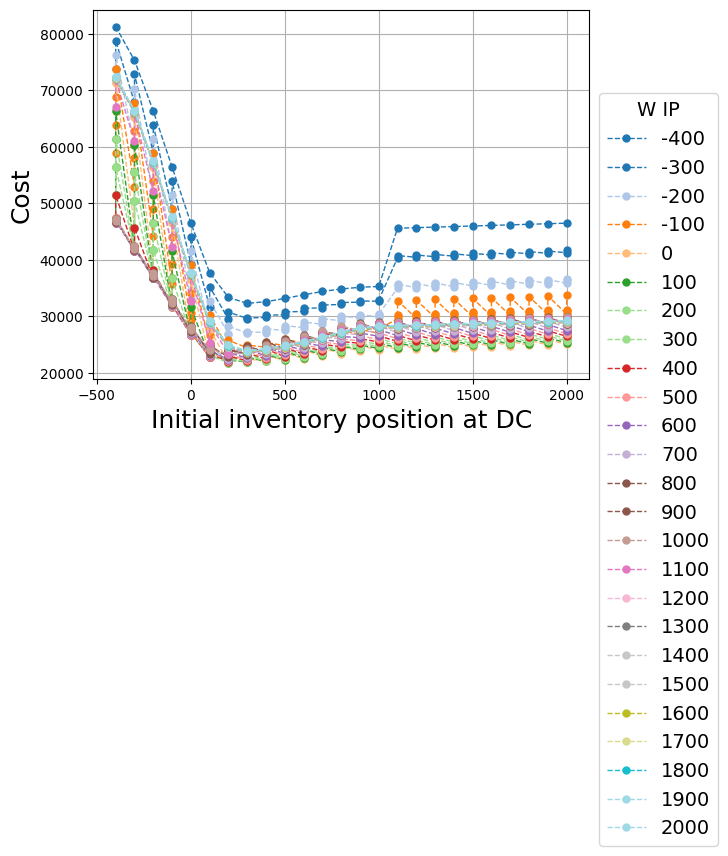

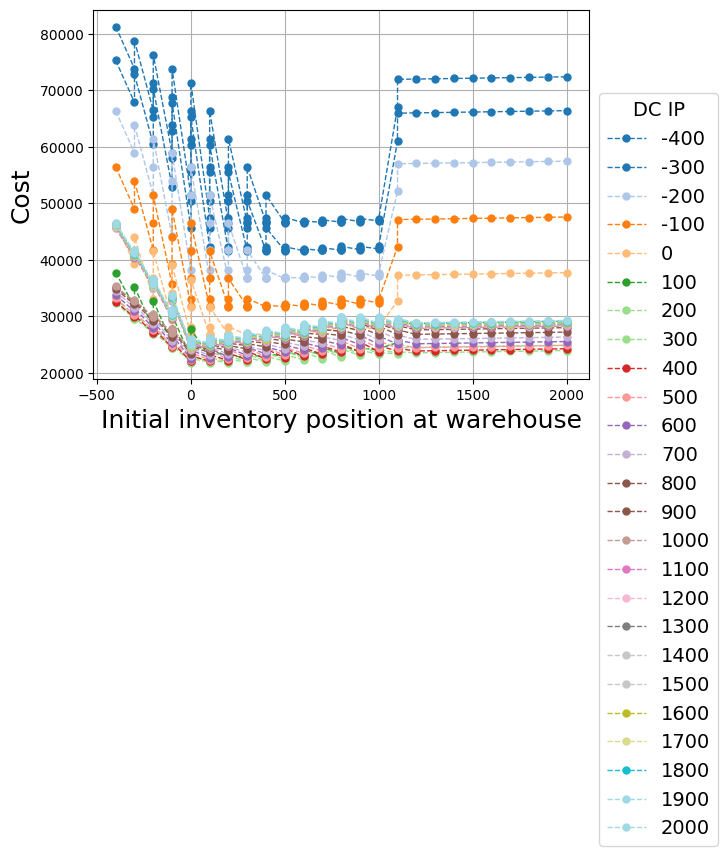

In [72]:
plot_cost(cL_cost_function, lead_times, 2, bbox_to_anchor=(1,0.8), colour_by = "W")
plot_cost(cL_cost_function, lead_times, 2, bbox_to_anchor=(1,0.8), colour_by="DC")

In [ ]:
# cL_optimal_policy

In [ ]:
# cL11_results = pickle.load(open(fr'PolicyResults/2ech_c1-1_cap400_MOQ600_sl98.0_gamma0.999.pkl', "rb"))
# cL11_policy = cL11_results["optimal_policy"]
# cL11_policy